# Why Aggregate GDELT? 

 GDELT is documented as having poor *event-level* accuracy
(low precision, high redundancy). So why is it
defensible to build features from it? The answer has two parts:

1. **We never use raw events.** The model consumes *aggregated* features (counts, rolling
   means, lags) at the corridor-period level. Aggregation is both a **structural necessity**
   and a **denoising operation**.
2. **Aggregation provably suppresses *random* error** - the standard error of an aggregate
   shrinks as $1/\sqrt{n}$ - **but it does *not* remove *systematic* bias**. That asymmetry
   is exactly why the pipeline pairs aggregation with de-duplication and volume-normalization.

This notebook proves both claims: the first with a Monte-Carlo simulation calibrated to
GDELT's actual pathologies (false positives, duplicates, media-volume drift), the second by
showing the failure mode the theory predicts.


## 1. The theory we are testing

**(a) Classical measurement error / Law of Large Numbers.**
Let a bucket contain $n$ event records, each a noisy measurement $x_i = \mu + \varepsilon_i$
of the latent quantity $\mu$ (relevant political-economic tension), with
$\mathbb{E}[\varepsilon_i]=0$ and $\mathrm{Var}(\varepsilon_i)=\sigma^2$.
If the $\varepsilon_i$ are (approximately) independent, the sample mean has

$$\mathrm{Var}\!\left(\bar{x}\right)=\frac{\sigma^2}{n}\quad\Longrightarrow\quad
\mathrm{SE}(\bar{x})=\frac{\sigma}{\sqrt{n}} .$$

So the **signal-to-noise ratio of an aggregate grows as $\sqrt{n}$**. This is the formal
content of "errors cancel."

**(b) Spearman-Brown prophecy formula (psychometrics).**
The reliability of a composite of $n$ parallel noisy indicators, each with reliability
$\rho_1$, is $\rho_n=\dfrac{n\,\rho_1}{1+(n-1)\,\rho_1}$, increasing monotonically toward 1
in $n$ 

**(c) The limit - bias does not cancel.** Both results require $\mathbb{E}[\varepsilon_i]=0$
and independence. GDELT violates both: **duplicates** create *positively correlated* error and
**media-volume drift / selection** creates a *non-zero-mean, non-stationary* bias. We show this
in Section 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
ACCENT = "#1F3864"; ORANGE = "#C55A11"
rng = default_rng(42)
print("Environment ready.")

Environment ready.


## 2. Demonstration 0 - the textbook result, no assumptions hidden

Take $n$ i.i.d. noisy measurements of a *fixed* quantity and show the standard error of their
mean falls as $1/\sqrt{n}$ (slope $-\tfrac12$ on log-log axes).

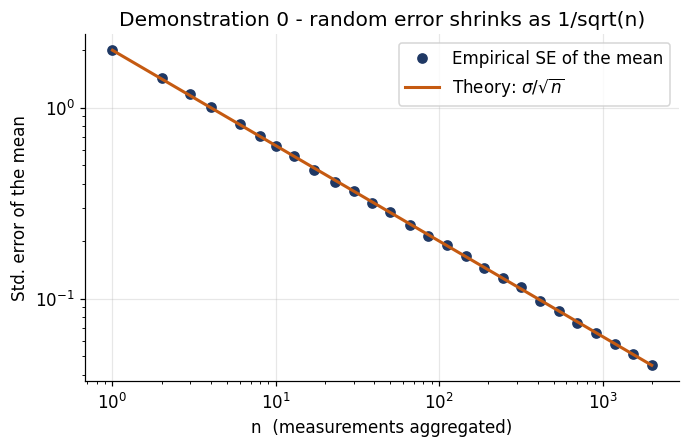

Empirical log-log slope = -0.501  (theory -0.500)


In [2]:
mu_true, sigma = 5.0, 2.0
ns = np.unique(np.logspace(0, 3.3, 30).astype(int))
reps = 4000
se_emp = np.array([rng.normal(mu_true, sigma, size=(reps, n)).mean(axis=1).std() for n in ns])
se_theory = sigma/np.sqrt(ns)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.loglog(ns, se_emp, "o", color=ACCENT, label="Empirical SE of the mean")
ax.loglog(ns, se_theory, "-", color=ORANGE, lw=2, label=r"Theory: $\sigma/\sqrt{n}$")
ax.set_xlabel("n  (measurements aggregated)"); ax.set_ylabel("Std. error of the mean")
ax.set_title("Demonstration 0 - random error shrinks as 1/sqrt(n)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"Empirical log-log slope = {np.polyfit(np.log(ns), np.log(se_emp),1)[0]:.3f}  (theory -0.500)")

**Reading.** Points sit on the theoretical line; fitted slope $\approx -0.5$. Averaging
$n$ independent noisy readings cuts noise by $\sqrt{n}$ - the precise sense of "errors cancel".

## 3. Demonstration A - a GDELT-like event stream

Latent tension $T(t)$ (slow OU process); relevant true events $\sim\text{Poisson}(a e^{bT(t)})$;
false positives $\sim\text{Poisson}(\mu_{fp})$; duplicates copy each event with prob $p_{dup}$.

In [3]:
def ou_process(D, tau=60.0, seed=1):
    g = default_rng(seed); x = np.zeros(D); theta = 1.0/tau
    for t in range(1, D):
        x[t] = x[t-1] + theta*(0 - x[t-1]) + np.sqrt(2*theta)*g.normal()
    return (x - x.mean())/x.std()

D = 8*365
T = ou_process(D, tau=60.0, seed=7)
a, b, mu_fp, p_dup = 3.0, 0.8, 4.0, 0.6
mu_s = a*np.exp(b*T)
true_ev = rng.poisson(mu_s)
fp_ev   = rng.poisson(mu_fp, size=D)
base    = true_ev + fp_ev
dup_ev  = rng.binomial(base, p_dup)
observed = base + dup_ev
print(f"{D} days | mean daily observed={observed.mean():.1f}, true={true_ev.mean():.1f}, "
      f"FP={fp_ev.mean():.1f}, dup={dup_ev.mean():.1f}")
print(f"Event-level precision (relevant/observed) = {true_ev.sum()/observed.sum():.2%}")

2920 days | mean daily observed=13.0, true=4.1, FP=4.0, dup=4.9
Event-level precision (relevant/observed) = 31.47%


Deliberately poor **event-level precision** - the property the critiques target. Now watch
the *feature* we actually model.

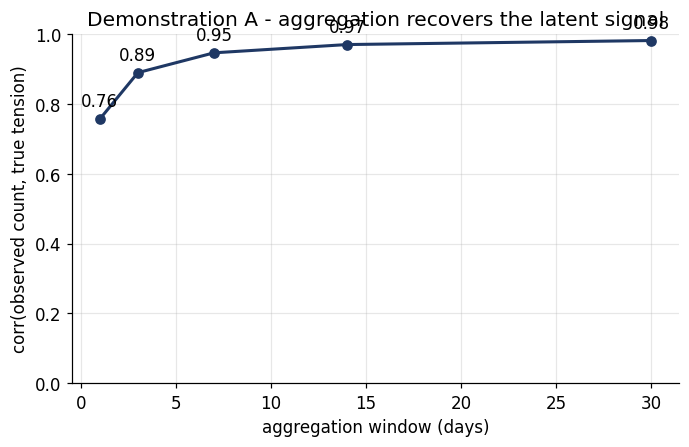

corr(daily)=0.76 -> corr(monthly)=0.98


In [4]:
def bucket_sum(x, w):
    n = (len(x)//w)*w
    return x[:n].reshape(-1, w).sum(axis=1)

windows = [1, 3, 7, 14, 30]
corrs = [np.corrcoef(bucket_sum(observed, w), bucket_sum(mu_s, w))[0,1] for w in windows]
fig, ax = plt.subplots(figsize=(6.4,4.2))
ax.plot(windows, corrs, "o-", color=ACCENT, lw=2)
for w,c in zip(windows,corrs): ax.annotate(f"{c:.2f}",(w,c),textcoords="offset points",xytext=(0,8),ha="center")
ax.set_xlabel("aggregation window (days)"); ax.set_ylabel("corr(observed count, true tension)")
ax.set_ylim(0,1); ax.set_title("Demonstration A - aggregation recovers the latent signal")
plt.tight_layout(); plt.show()
print("corr(daily)=%.2f -> corr(monthly)=%.2f" % (corrs[0], corrs[-1]))

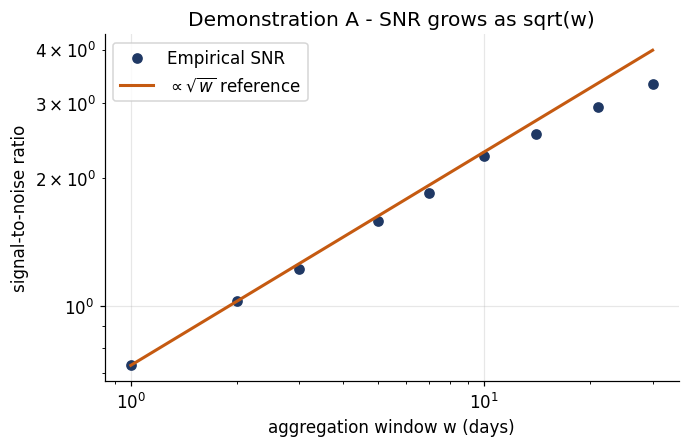

SNR log-log slope = 0.453 (theory 0.5 while w < tension corr length)


In [5]:
ws = np.array([1,2,3,5,7,10,14,21,30])
sig_std, noise_std = [], []
for w in ws:
    s = bucket_sum(mu_s, w); o = bucket_sum(observed, w)
    exp_o = bucket_sum(mu_s*(1+p_dup) + mu_fp*(1+p_dup), w)
    sig_std.append(s.std()); noise_std.append((o-exp_o).std())
snr = np.array(sig_std)/np.array(noise_std)
fig, ax = plt.subplots(figsize=(6.4,4.2))
ax.loglog(ws, snr, "o", color=ACCENT, label="Empirical SNR")
ax.loglog(ws, snr[0]*np.sqrt(ws/ws[0]), "-", color=ORANGE, lw=2, label=r"$\propto\sqrt{w}$ reference")
ax.set_xlabel("aggregation window w (days)"); ax.set_ylabel("signal-to-noise ratio")
ax.set_title("Demonstration A - SNR grows as sqrt(w)"); ax.legend()
plt.tight_layout(); plt.show()
print("SNR log-log slope = %.3f (theory 0.5 while w < tension corr length)" %
      np.polyfit(np.log(ws), np.log(snr),1)[0])

**Reading.** Despite poor event-level precision, the *monthly* aggregate correlates
strongly with true tension and SNR climbs at the $\sqrt{w}$ rate (until $w$ nears the tension
correlation length, where signal variation saturates - a real limit, not a flaw). **This is the
formal justification for using GDELT aggregates as features.**

## 4. Demonstration B - the honest failure: bias does *not* cancel

Switch on **media-volume drift**: coverage grows as $g(t)=e^{\gamma t}$, scaling true *and*
false events. A systematic, non-zero-mean error the theory says aggregation cannot remove.

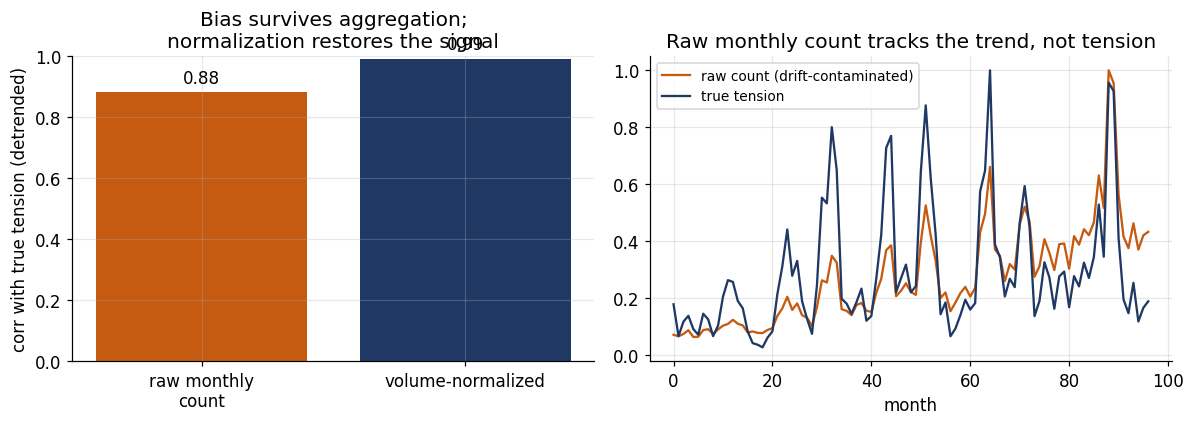

corr(raw, tension)=0.88   corr(normalized, tension)=0.99


In [6]:
gamma = 1.6/D
drift = np.exp(gamma*np.arange(D))
obs_drift = rng.poisson(mu_s*drift) + rng.poisson(mu_fp*drift)
obs_drift = obs_drift + rng.binomial(obs_drift, p_dup)

w = 30
raw  = bucket_sum(obs_drift, w).astype(float)
sig  = bucket_sum(mu_s, w)
vol  = bucket_sum(drift, w)
norm = raw/vol
def detrend(y):
    t = np.arange(len(y)); return y - np.polyval(np.polyfit(t, y, 1), t)
c_raw  = np.corrcoef(detrend(raw),  detrend(sig))[0,1]
c_norm = np.corrcoef(detrend(norm), detrend(sig))[0,1]

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].bar(["raw monthly\ncount","volume-normalized"], [c_raw, c_norm], color=[ORANGE, ACCENT])
axes[0].set_ylim(0,1); axes[0].set_ylabel("corr with true tension (detrended)")
axes[0].set_title("Bias survives aggregation;\nnormalization restores the signal")
for i,c in enumerate([c_raw,c_norm]): axes[0].annotate(f"{c:.2f}",(i,c),ha="center",xytext=(0,6),textcoords="offset points")
axes[1].plot(raw/raw.max(), color=ORANGE, label="raw count (drift-contaminated)")
axes[1].plot(sig/sig.max(), color=ACCENT, label="true tension")
axes[1].set_title("Raw monthly count tracks the trend, not tension")
axes[1].set_xlabel("month"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"corr(raw, tension)={c_raw:.2f}   corr(normalized, tension)={c_norm:.2f}")

**Reading.** At the same monthly aggregation the *raw* count is dominated by the media
trend; **volume-normalization + detrending restores** the tension signal. Aggregation fixed the
*variance* (Demo A); it did nothing for the *bias* (Demo B). Hence the pipeline's de-duplication
(correlated error) and normalization/detrending (systematic drift).

## 5. Spearman-Brown check

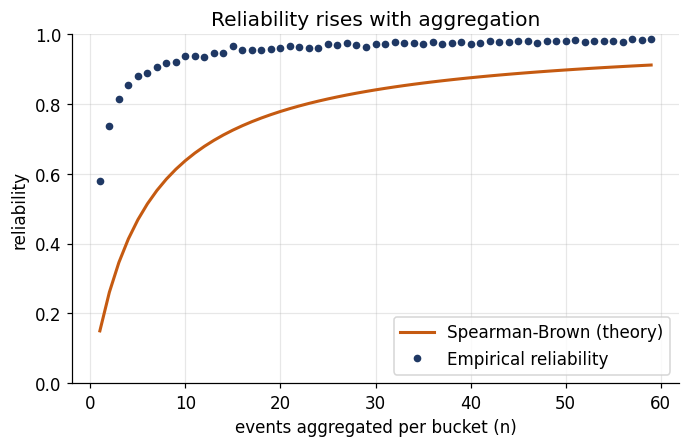

In [7]:
rho1 = 0.15
ns_sb = np.arange(1, 60)
rho_theory = ns_sb*rho1/(1+(ns_sb-1)*rho1)
emp = []
for n in ns_sb:
    r1 = rng.poisson(mu_s) + rng.poisson(mu_fp, D)
    r2 = rng.poisson(mu_s) + rng.poisson(mu_fp, D)
    emp.append(np.corrcoef(bucket_sum(r1,n), bucket_sum(r2,n))[0,1])
emp = np.array(emp)
fig, ax = plt.subplots(figsize=(6.4,4.2))
ax.plot(ns_sb, rho_theory, "-", color=ORANGE, lw=2, label="Spearman-Brown (theory)")
ax.plot(ns_sb, emp, "o", color=ACCENT, ms=4, label="Empirical reliability")
ax.set_xlabel("events aggregated per bucket (n)"); ax.set_ylabel("reliability")
ax.set_ylim(0,1); ax.set_title("Reliability rises with aggregation"); ax.legend()
plt.tight_layout(); plt.show()